# Merge 3 Dataset và Visualization

## 1. Tổng quan các dataset

In [1]:
from pathlib import Path

# Đường dẫn tới các dataset
BASE_DIR = Path("/Users/mac/MeterReadAI/data/DataForTrain")

DATASETS = {
    "water_meters": BASE_DIR / "water_meters",
    "word_wheel_water_meter": BASE_DIR / "word_wheel_water_meter",
    "ocr_water_meter": BASE_DIR / "ocr_water_meter"
}

# Kiểm tra số lượng ảnh trong mỗi dataset
for name, dataset_path in DATASETS.items():
    print(f"\n=== {name} ===")
    for split in ["train", "val", "test"]:
        img_dir = dataset_path / "images" / split
        label_dir = dataset_path / "labels" / split
        
        if img_dir.exists():
            num_images = len(list(img_dir.glob("*.*")))
            num_labels = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0
            print(f"  {split}: {num_images} images, {num_labels} labels")


=== water_meters ===
  train: 995 images, 995 labels
  val: 124 images, 124 labels
  test: 125 images, 125 labels

=== word_wheel_water_meter ===
  train: 29436 images, 29436 labels
  val: 3270 images, 3270 labels
  test: 13391 images, 13391 labels

=== ocr_water_meter ===
  train: 9273 images, 9273 labels
  val: 880 images, 880 labels
  test: 445 images, 445 labels


## 2. Merge 3 dataset thành 1 thư mục merge_dataset

In [2]:
from pathlib import Path
import shutil

# Thư mục đích
OUTPUT_DIR = Path("/Users/mac/MeterReadAI/data/DataForTrain/merge_dataset")

# Tạo cấu trúc thư mục
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print(f"Đã tạo cấu trúc thư mục tại: {OUTPUT_DIR}")

Đã tạo cấu trúc thư mục tại: /Users/mac/MeterReadAI/data/DataForTrain/merge_dataset


In [3]:
# Merge tất cả dataset
total_copied = {"train": 0, "val": 0, "test": 0}

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n=== Đang merge {dataset_name} ===")
    
    for split in ["train", "val", "test"]:
        src_img_dir = dataset_path / "images" / split
        src_label_dir = dataset_path / "labels" / split
        
        dst_img_dir = OUTPUT_DIR / "images" / split
        dst_label_dir = OUTPUT_DIR / "labels" / split
        
        if not src_img_dir.exists():
            print(f"  {split}: Bỏ qua (thư mục không tồn tại)")
            continue
        
        # Copy images
        img_files = list(src_img_dir.glob("*.*"))
        for img_file in img_files:
            # Đặt tên file mới với prefix tên dataset để tránh trùng tên
            new_name = f"{dataset_name}_{img_file.name}"
            shutil.copy2(img_file, dst_img_dir / new_name)
        
        # Copy labels
        if src_label_dir.exists():
            label_files = list(src_label_dir.glob("*.txt"))
            for label_file in label_files:
                new_name = f"{dataset_name}_{label_file.name}"
                shutil.copy2(label_file, dst_label_dir / new_name)
        
        total_copied[split] += len(img_files)
        print(f"  {split}: Đã copy {len(img_files)} images")

print(f"\n=== Tổng kết ===")
for split, count in total_copied.items():
    print(f"{split}: {count} images")


=== Đang merge water_meters ===
  train: Đã copy 995 images
  val: Đã copy 124 images
  test: Đã copy 125 images

=== Đang merge word_wheel_water_meter ===
  train: Đã copy 29436 images
  val: Đã copy 3270 images
  test: Đã copy 13391 images

=== Đang merge ocr_water_meter ===
  train: Đã copy 9273 images
  val: Đã copy 880 images
  test: Đã copy 445 images

=== Tổng kết ===
train: 39704 images
val: 4274 images
test: 13961 images


In [4]:
# Kiểm tra kết quả merge
print("=== Kiểm tra thư mục merge_dataset ===")
for split in ["train", "val", "test"]:
    img_dir = OUTPUT_DIR / "images" / split
    label_dir = OUTPUT_DIR / "labels" / split
    
    num_images = len(list(img_dir.glob("*.*")))
    num_labels = len(list(label_dir.glob("*.txt")))
    
    print(f"{split}: {num_images} images, {num_labels} labels")

=== Kiểm tra thư mục merge_dataset ===
train: 39704 images, 39704 labels
val: 4274 images, 4274 labels
test: 13961 images, 13961 labels


## 3. Visualize 10 ảnh từ mỗi split

In [5]:
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(split, num_samples=10):
    """Visualize ngẫu nhiên num_samples ảnh từ split được chọn"""
    img_dir = OUTPUT_DIR / "images" / split
    label_dir = OUTPUT_DIR / "labels" / split
    
    # Lấy danh sách ảnh
    img_files = list(img_dir.glob("*.*"))
    
    # Chọn ngẫu nhiên
    random.seed(42)
    selected = random.sample(img_files, min(num_samples, len(img_files)))
    
    # Tạo figure
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for ax, img_path in zip(axes, selected):
        # Đọc ảnh
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Đọc label tương ứng
        label_path = label_dir / f"{img_path.stem}.txt"
        
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) >= 7:
                        # Bỏ class_id
                        coords = list(map(float, values[1:]))
                        
                        # Chuyển normalized → pixel
                        points = []
                        for i in range(0, len(coords), 2):
                            x = int(coords[i] * w)
                            y = int(coords[i + 1] * h)
                            points.append([x, y])
                        
                        # Vẽ polygon
                        points = np.array(points, dtype="int32")
                        cv2.polylines(image, [points], True, (255, 0, 0), 3)
                        
                        # Tô nhẹ bên trong
                        overlay = image.copy()
                        cv2.fillPoly(overlay, [points], (255, 0, 0))
                        image = cv2.addWeighted(overlay, 0.2, image, 0.8, 0)
        
        ax.imshow(image)
        ax.set_title(img_path.name[:20])  # Rút gọn tên file
        ax.axis("off")
    
    plt.suptitle(f"Merged Dataset - {split.upper()} Split ({len(selected)} samples)", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"Đã visualize {len(selected)} ảnh từ {split} split")

### 3.1 Visualize 10 ảnh từ Train Split

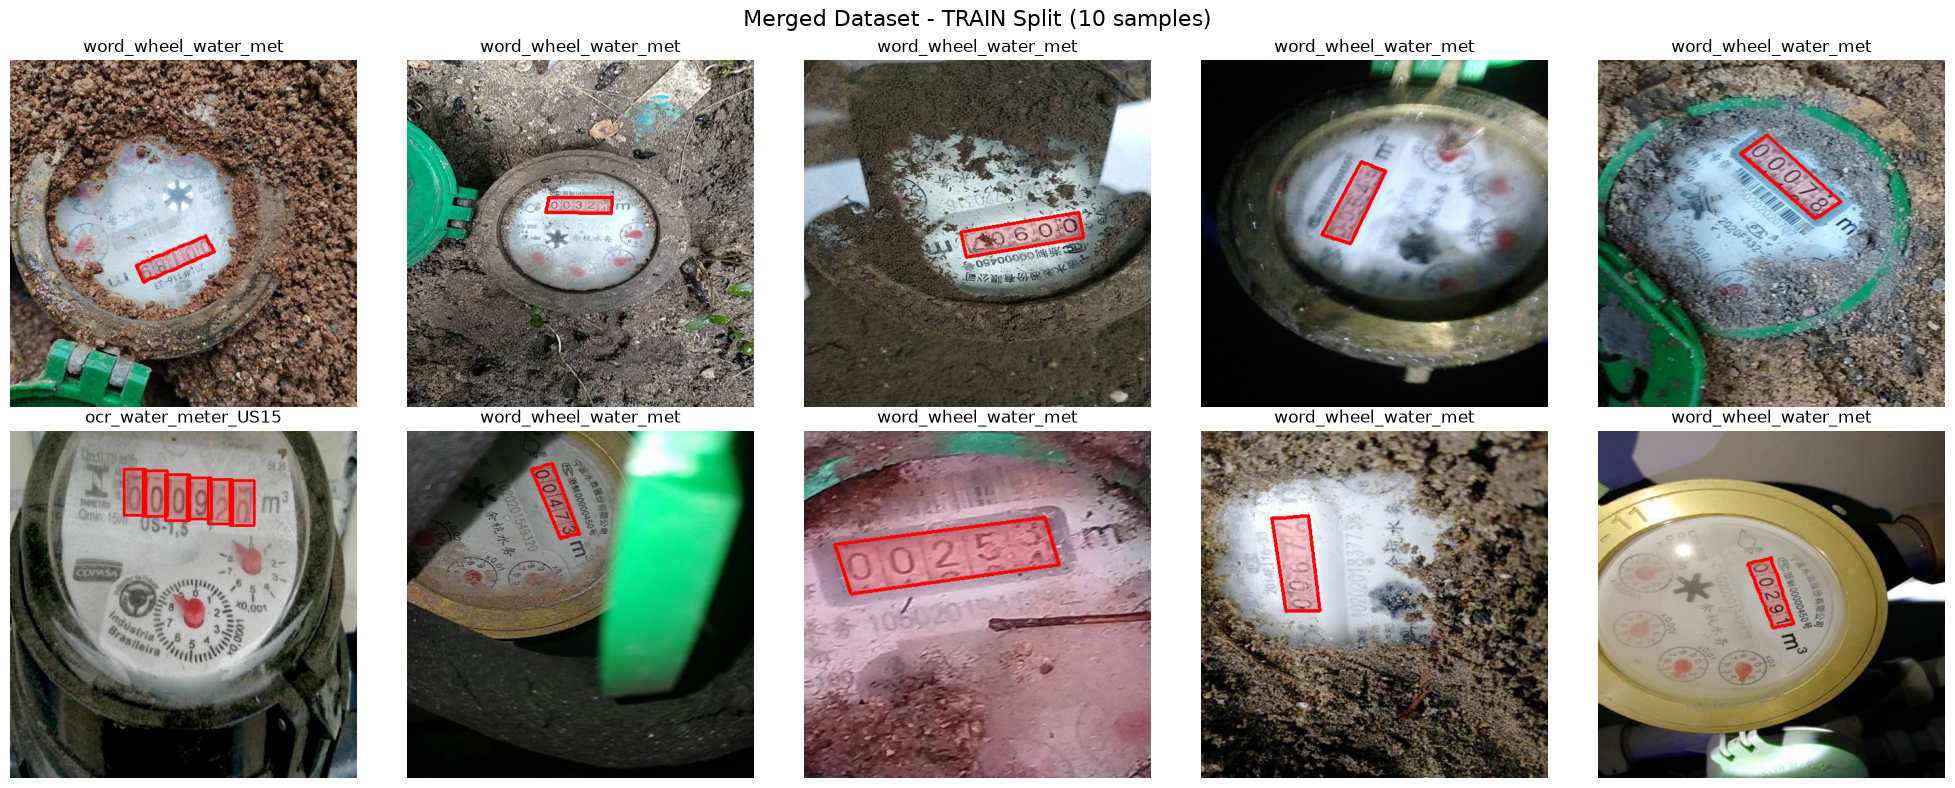

Đã visualize 10 ảnh từ train split


In [6]:
visualize_samples("train", num_samples=10)

### 3.2 Visualize 10 ảnh từ Val Split

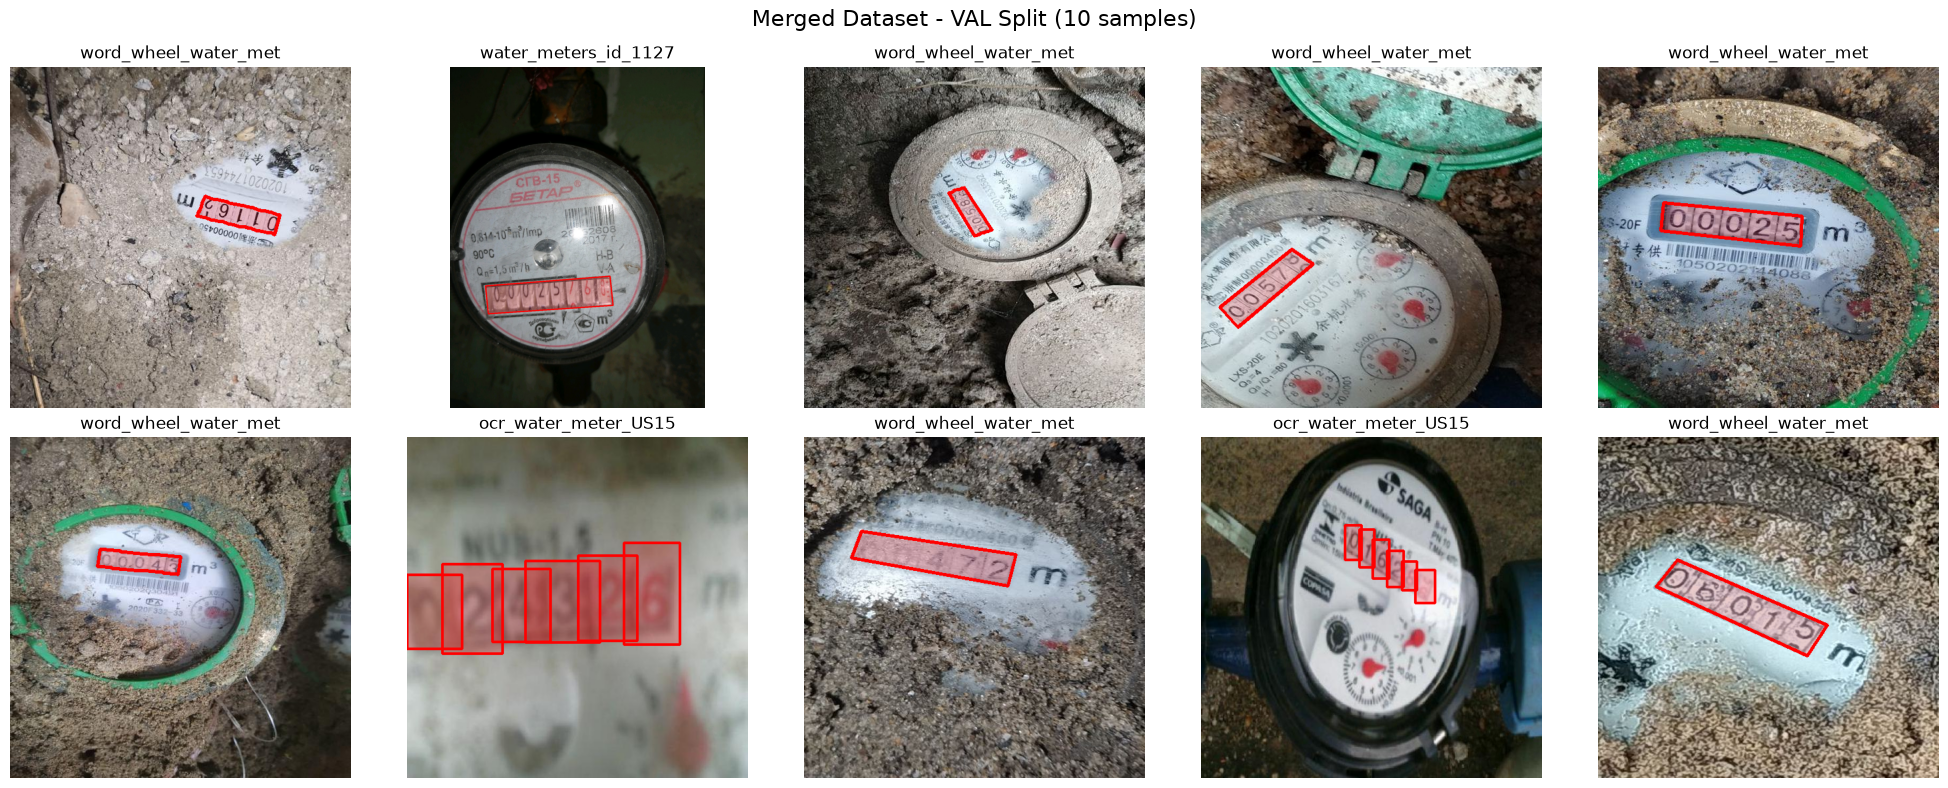

Đã visualize 10 ảnh từ val split


In [7]:
visualize_samples("val", num_samples=10)

### 3.3 Visualize 10 ảnh từ Test Split

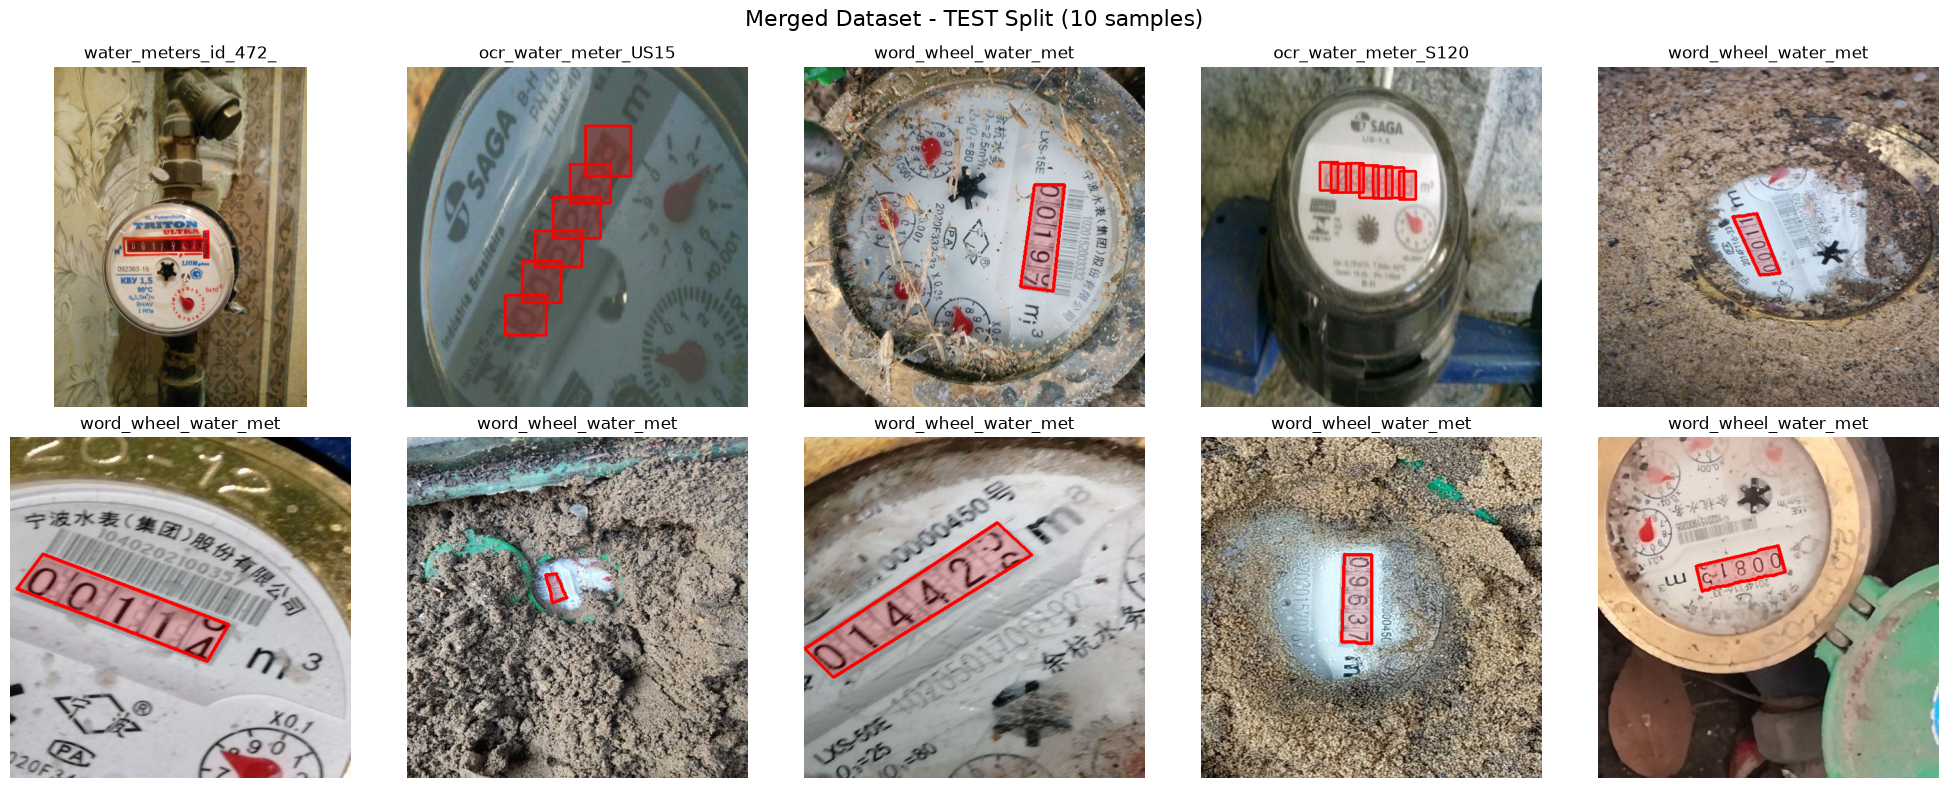

Đã visualize 10 ảnh từ test split


In [8]:
visualize_samples("test", num_samples=10)

## 4. Thống kê tổng quan merged dataset

In [9]:
print("=== THỐNG KÊ TỔNG QUAN MERGED DATASET ===")
print(f"Thư mục: {OUTPUT_DIR}")
print()

total_images = 0
total_labels = 0

for split in ["train", "val", "test"]:
    img_dir = OUTPUT_DIR / "images" / split
    label_dir = OUTPUT_DIR / "labels" / split
    
    num_images = len(list(img_dir.glob("*.*")))
    num_labels = len(list(label_dir.glob("*.txt")))
    
    total_images += num_images
    total_labels += num_labels
    
    print(f"{split.upper():5}: {num_images:6} images, {num_labels:6} labels")

print()
print(f"TỔNG CỘNG: {total_images} images, {total_labels} labels")

# Kiểm tra xem có ảnh nào thiếu label không
missing_labels = []
for split in ["train", "val", "test"]:
    img_dir = OUTPUT_DIR / "images" / split
    label_dir = OUTPUT_DIR / "labels" / split
    
    for img_file in img_dir.glob("*.*"):
        label_file = label_dir / f"{img_file.stem}.txt"
        if not label_file.exists():
            missing_labels.append((split, img_file.name))

if missing_labels:
    print(f"\n⚠️ Cảnh báo: {len(missing_labels)} ảnh thiếu label")
    for split, name in missing_labels[:5]:
        print(f"  - {split}/{name}")
else:
    print("\n✅ Tất cả ảnh đều có label tương ứng")

=== THỐNG KÊ TỔNG QUAN MERGED DATASET ===
Thư mục: /Users/mac/MeterReadAI/data/DataForTrain/merge_dataset

TRAIN:  39704 images,  39704 labels
VAL  :   4274 images,   4274 labels
TEST :  13961 images,  13961 labels

TỔNG CỘNG: 57939 images, 57939 labels

✅ Tất cả ảnh đều có label tương ứng


## 5. Phân tích nguồn gốc của ảnh trong merged dataset

In [10]:
from collections import Counter

print("=== PHÂN PHỐI ẢNH THEO NGUỒN DATASET ===")
print()

for split in ["train", "val", "test"]:
    img_dir = OUTPUT_DIR / "images" / split
    img_files = list(img_dir.glob("*.*"))
    
    # Đếm theo nguồn (prefix tên file)
    sources = Counter()
    for img_file in img_files:
        # Lấy prefix (tên dataset)
        parts = img_file.name.split("_")
        if len(parts) >= 2:
            source = parts[0]
            sources[source] += 1
    
    print(f"{split.upper()} split:")
    for source, count in sources.items():
        percentage = (count / len(img_files)) * 100
        print(f"  - {source:25}: {count:6} ({percentage:5.1f}%)")
    print(f"  Tổng cộng: {len(img_files)} images")
    print()

=== PHÂN PHỐI ẢNH THEO NGUỒN DATASET ===

TRAIN split:
  - word                     :  29436 ( 74.1%)
  - ocr                      :   9273 ( 23.4%)
  - water                    :    995 (  2.5%)
  Tổng cộng: 39704 images

VAL split:
  - word                     :   3270 ( 76.5%)
  - ocr                      :    880 ( 20.6%)
  - water                    :    124 (  2.9%)
  Tổng cộng: 4274 images

TEST split:
  - word                     :  13391 ( 95.9%)
  - water                    :    125 (  0.9%)
  - ocr                      :    445 (  3.2%)
  Tổng cộng: 13961 images

